# CNN for MNIST Digit Classification

This notebook downloads the MNIST dataset directly using TensorFlow, builds a Convolutional Neural Network (CNN), trains it, evaluates it, and makes predictions.

## 1. Import Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


## 2. Download MNIST Dataset

The dataset is downloaded automatically. No manual upload is required.

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print('Training images:', x_train.shape)
print('Training labels:', y_train.shape)
print('Testing images:', x_test.shape)
print('Testing labels:', y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


## 3. Display a Sample Image

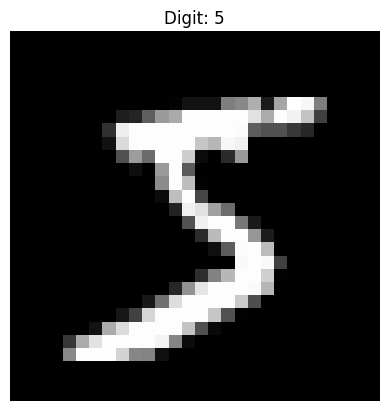

In [3]:
plt.imshow(x_train[0], cmap='gray')
plt.title(f'Digit: {y_train[0]}')
plt.axis('off')
plt.show()

## 4. Preprocess the Data

Pixel values are normalized from 0–255 to 0–1, and a channel dimension is added for CNN input.

In [4]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print('Training shape:', x_train.shape)
print('Testing shape:', x_test.shape)

Training shape: (60000, 28, 28, 1)
Testing shape: (10000, 28, 28, 1)


## 5. Build the CNN Model

In [5]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Compile the Model

In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 7. Train the CNN

In [7]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 50s 57ms/step - accuracy: 0.9481 - loss: 0.1729 - val_accuracy: 0.9838 - val_loss: 0.0554
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 54ms/step - accuracy: 0.9842 - loss: 0.0506 - val_accuracy: 0.9878 - val_loss: 0.0422
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 82s 55ms/step - accuracy: 0.9886 - loss: 0.0357 - val_accuracy: 0.9875 - val_loss: 0.0389
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 48s 57ms/step - accuracy: 0.9917 - loss: 0.0266 - val_accuracy: 0.9847 - val_loss: 0.0493
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 80s 54ms/step - accuracy: 0.9935 - loss: 0.0203 - val_accuracy: 0.9917 - val_loss: 0.0350


## 8. Evaluate the Model

In [8]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print('Test Loss:', test_loss)
print('Test Accuracy:', test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9904 - loss: 0.0286
Test Loss: 0.028584616258740425
Test Accuracy: 0.9904000163078308


## 9. Plot Training and Validation Accuracy

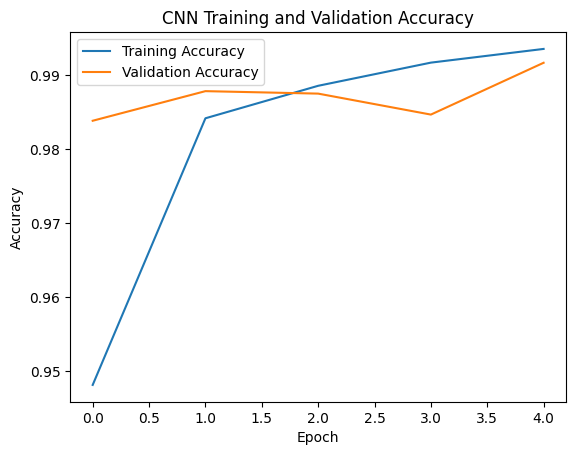

In [9]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Training and Validation Accuracy')
plt.legend()
plt.show()

## 10. Make a Prediction

In [10]:
index = 0

prediction = model.predict(x_test[index].reshape(1, 28, 28, 1), verbose=0)
predicted_digit = np.argmax(prediction)

print('Actual digit:', y_test[index])
print('Predicted digit:', predicted_digit)

Actual digit: 7
Predicted digit: 7


## 11. Display the Prediction

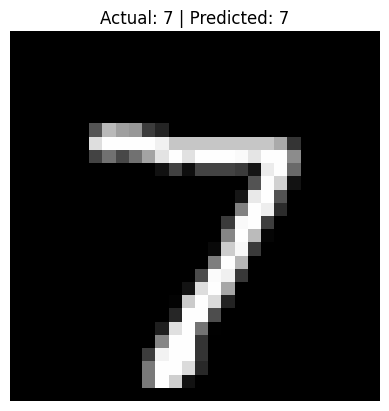

In [11]:
plt.imshow(x_test[index].reshape(28, 28), cmap='gray')
plt.title(f'Actual: {y_test[index]} | Predicted: {predicted_digit}')
plt.axis('off')
plt.show()